# A Simple Language Model with a Recurrent Neural Network

In the previous module we trained a **Multi-Layer Perceptron (MLP)** to classify handwritten digits. An MLP sees a fixed-size input vector all at once — it has no notion of *order* or *sequence*. 

Many interesting problems, however, involve sequences: time-series data, audio signals, lightcurves, spectra, and — the focus of this notebook — **natural language**. To model these, we need a network that reads input one piece at a time and remembers what it has seen.

A **Recurrent Neural Network (RNN)** does exactly that. It maintains an internal *hidden state* that is updated at each step:

$$
h_t = \tanh(W_x\, x_t + W_h\, h_{t-1} + b)
$$

If this looks like the update rule for a discrete-time dynamical system, that's because it is one. The hidden state $h_t$ is a learned summary of the entire history $x_1, x_2, \ldots, x_t$, much like the state vector of a physical system encodes its past via its current configuration.

By the end of this notebook you will have:
- Downloaded and tokenised a real text corpus (the works of Shakespeare)
- Built an RNN-based **language model** that predicts the next word given the words so far
- Visualised the learned word embeddings *before* and *after* training
- Used the trained model to **complete short sentences**
- Explored how the hidden-state size and context window length affect performance

## 1. Imports and Setup

We use the same minimal stack as in the MLP notebook, plus a couple of standard-library modules for downloading and counting text:
- **torch** — the core PyTorch library
- **numpy** — numerical arrays
- **matplotlib** — plotting
- **urllib** — to download the text file (built in, no install needed)
- **collections.Counter** — to count word frequencies (built in)

In [1]:
%matplotlib inline

import os
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import random

# Fix random seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


## 2. Download and Explore the Text

We use the **Tiny Shakespeare** corpus — roughly 40,000 lines from Shakespeare's plays concatenated into a single text file (~1 MB). It is a classic teaching dataset for language models: small enough to train on a laptop, but rich enough that the trained model produces recognisably Shakespearean output.

The file is hosted publicly by Andrej Karpathy (creator of the `char-rnn` project that popularised it). We download it once with `urllib`.

In [2]:
DATA_DIR = './data'
TEXT_PATH = os.path.join(DATA_DIR, 'tinyshakespeare.txt')
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

os.makedirs(DATA_DIR, exist_ok=True)

# Download only if we haven't already
if not os.path.exists(TEXT_PATH):
    print(f"Downloading Tiny Shakespeare from {URL} ...")
    urllib.request.urlretrieve(URL, TEXT_PATH)
    print("Done.")
else:
    print("Text file already downloaded.")

# Read the entire file into a single Python string
with open(TEXT_PATH, 'r', encoding='utf-8') as f:
    raw_text = f.read()

print(f"\nTotal characters: {len(raw_text):,}")
print("\n--- First 500 characters ---")
print(raw_text[:500])

Text file already downloaded.

Total characters: 1,115,394

--- First 500 characters ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 3. Tokenise the Text

A **token** is the basic unit the model processes. Real production language models use sophisticated *subword* tokenisers (BPE, WordPiece, etc.) that split words into smaller pieces, but for this notebook we use the simplest possible scheme: **whitespace-separated words, all lower-case**.

We also strip nothing else — punctuation stays attached to neighbouring words. This means `'love,'`, `'love.'`, and `'love'` end up as three *different* tokens, which is part of why the raw vocabulary is so large. This is intentionally crude, but easy to read and inspect.

The full vocabulary of Tiny Shakespeare has tens of thousands of unique tokens. Most of them appear only once or twice — too rarely to learn anything reliable about. So we **cap the vocabulary** at the most frequent `VOCAB_SIZE` tokens, replacing the rest with a special `<unk>` (unknown) token. This is directly analogous to **binning sparse data** in a histogram: rare bins are noisy, and aggregating them produces a more useful summary.

In [3]:
# Convert to lower-case and split on whitespace
tokens = raw_text.lower().split()

print(f"Total tokens (words): {len(tokens):,}")
print(f"Unique tokens       : {len(set(tokens)):,}")
print("\nFirst 20 tokens:")
print(tokens[:20])

Total tokens (words): 202,651
Unique tokens       : 23,641

First 20 tokens:
['first', 'citizen:', 'before', 'we', 'proceed', 'any', 'further,', 'hear', 'me', 'speak.', 'all:', 'speak,', 'speak.', 'first', 'citizen:', 'you', 'are', 'all', 'resolved', 'rather']


In [4]:
# Cap the vocabulary at the most frequent VOCAB_SIZE - 1 words.
# We reserve index 0 for a special <unk> token used for any word not in the vocab.
VOCAB_SIZE = 5000

# Counter.most_common(n) returns the n most frequent items with their counts
word_counts = Counter(tokens)
most_common = word_counts.most_common(VOCAB_SIZE - 1)  # leave room for <unk>

# Build the mappings between words and integer indices
idx_to_word = ['<unk>'] + [word for word, _ in most_common]
word_to_idx = {word: i for i, word in enumerate(idx_to_word)}

print(f"Vocabulary size: {len(idx_to_word):,}")
print("\nMost common words:")
for word, count in most_common[:10]:
    print(f"  {word!r:15s}  {count:,}")

# Convert the whole corpus to a long sequence of integer indices.
# Any word not in the vocab maps to <unk> (index 0).
data_indices = [word_to_idx.get(w, 0) for w in tokens]
data_tensor = torch.tensor(data_indices, dtype=torch.long)

# Fraction of tokens that fell out of the vocab (became <unk>)
unk_fraction = (data_tensor == 0).float().mean().item()
print(f"\nFraction of tokens mapped to <unk>: {unk_fraction:.1%}")

Vocabulary size: 5,000

Most common words:
  'the'            6,279
  'and'            5,479
  'to'             4,723
  'i'              4,403
  'of'             3,721
  'my'             3,114
  'a'              2,975
  'you'            2,449
  'that'           2,427
  'in'             2,312

Fraction of tokens mapped to <unk>: 12.5%


## 4. Build Training Sequences

The model's task is: **given the previous `seq_len` words, predict the next word.**

We slide a window of length `seq_len + 1` across the corpus. For each window:
- The first `seq_len` indices become the **input** sequence
- The last `seq_len` indices become the **target** sequence (each target is the next word for the corresponding input position)

Concretely, if the corpus reads `the quick brown fox jumps over` and `seq_len = 4`, one training example is:
```
input  : the   quick brown fox
target : quick brown fox   jumps
```
The model is asked, at every position, to predict the next word given everything to its left.

Note that the windows we build overlap heavily: each token appears in roughly `seq_len` different training windows, but at a different position within each one. This is standard practice for language-model training — it gives the network many more chances to learn from each token without any leakage between train and test (the train/test split happens *before* we slice into windows).

In [5]:
SEQ_LEN = 20  # number of words of context the model sees at once

# Split the corpus into train / test (90% / 10%).
# Because this is sequential data we split by position, not at random.
split = int(0.9 * len(data_tensor))
train_data = data_tensor[:split]
test_data  = data_tensor[split:]

print(f"Training tokens: {len(train_data):,}")
print(f"Test tokens    : {len(test_data):,}")


def make_sequences(data, seq_len):
    """
    Slice `data` into overlapping (input, target) sequence pairs.
    Each input has length seq_len, and the target is the same sequence shifted by one.
    """
    # Number of complete (input, target) windows we can extract.
    # We subtract seq_len because the last input must have a target one step beyond it.
    n_sequences = len(data) - seq_len

    inputs  = torch.zeros((n_sequences, seq_len), dtype=torch.long)
    targets = torch.zeros((n_sequences, seq_len), dtype=torch.long)

    for i in range(n_sequences):
        inputs[i]  = data[i     : i + seq_len]
        targets[i] = data[i + 1 : i + seq_len + 1]

    return inputs, targets


train_inputs, train_targets = make_sequences(train_data, SEQ_LEN)
test_inputs,  test_targets  = make_sequences(test_data,  SEQ_LEN)

print(f"\nTraining sequences: {len(train_inputs):,}")
print(f"Test sequences    : {len(test_inputs):,}")

# Show what one (input, target) pair looks like as words
print("\nExample training pair:")
print("  input :", ' '.join(idx_to_word[i] for i in train_inputs[0].tolist()))
print("  target:", ' '.join(idx_to_word[i] for i in train_targets[0].tolist()))

Training tokens: 182,385
Test tokens    : 20,266

Training sequences: 182,365
Test sequences    : 20,246

Example training pair:
  input : first citizen: before we proceed any further, hear me speak. all: speak, speak. first citizen: you are all resolved rather
  target: citizen: before we proceed any further, hear me speak. all: speak, speak. first citizen: you are all resolved rather to


In [6]:
# Wrap the (input, target) tensors in a DataLoader for easy mini-batching during training.
BATCH_SIZE = 64

train_dataset = TensorDataset(train_inputs, train_targets)
test_dataset  = TensorDataset(test_inputs,  test_targets)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

## 5. Define the RNN Language Model

Our model has three components:

1. **Embedding layer** (`nn.Embedding`). A learned lookup table mapping each word index to a dense vector of size `embed_dim`. Think of it as assigning every word a position in an `embed_dim`-dimensional feature space — words used in similar contexts should end up nearby. This is conceptually similar to assigning each particle species a feature vector instead of a one-hot label.

2. **RNN layer** (`nn.RNN`). Takes the embedded sequence and produces a hidden state at every time step using the update rule

   $$h_t = \tanh(W_x\, x_t + W_h\, h_{t-1} + b).$$

   The same weights $W_x, W_h, b$ are reused at every time step — this *weight sharing* is what makes the network "recurrent" and lets it handle sequences of arbitrary length with a fixed parameter count.

3. **Output linear layer** (`nn.Linear`). At each time step, projects the hidden state into a vector of size `vocab_size`. These are the unnormalised scores ("logits") for each possible next word.

Just like the MLP class in the previous module, we make the sizes configurable so we can experiment later.

In [7]:
class RNNLanguageModel(nn.Module):
    """
    A simple word-level language model:
        word indices  ->  embedding  ->  RNN  ->  linear  ->  word-score logits

    Parameters
    ----------
    vocab_size : int
        Number of distinct word indices the model must handle.
    embed_dim : int
        Dimensionality of the learned word-embedding vectors.
    hidden_dim : int
        Size of the RNN hidden state. Larger = more capacity to remember context.
    n_layers : int
        Number of stacked RNN layers. Each layer's output feeds the next.
    """
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, n_layers=1):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # Embedding: a (vocab_size x embed_dim) lookup table of learned vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Plain RNN with tanh nonlinearity.
        # batch_first=True means inputs have shape (batch, seq_len, features)
        # instead of PyTorch's default (seq_len, batch, features).
        # The default convention is convenient for GPU work but confusing
        # to read — we use the more intuitive batch-first ordering here.
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            nonlinearity='tanh',
            batch_first=True,
        )

        # Project hidden state -> one score per vocabulary word
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        Parameters
        ----------
        x : LongTensor of shape (batch, seq_len)
            Word indices.
        hidden : optional initial hidden state.
            If None, PyTorch initialises it to zeros.

        Returns
        -------
        logits : FloatTensor of shape (batch, seq_len, vocab_size)
            Score for each vocabulary word at every position.
        hidden : final hidden state (useful for continuing generation).
        """
        # Look up an embedding vector for each input word index.
        # shape: (batch, seq_len) -> (batch, seq_len, embed_dim)
        embedded = self.embedding(x)

        # Run the embedded sequence through the RNN.
        # `rnn_out` has shape (batch, seq_len, hidden_dim) — the hidden state
        # at every position. `hidden` is the final hidden state only.
        rnn_out, hidden = self.rnn(embedded, hidden)

        # Apply the output layer to every position in parallel.
        # shape: (batch, seq_len, hidden_dim) -> (batch, seq_len, vocab_size)
        logits = self.output(rnn_out)

        return logits, hidden


# Create a default model and print its structure.
# We deliberately keep the model small: with only ~180k training tokens,
# a larger network overfits quickly (memorises the training plays
# rather than learning patterns that transfer to held-out text).
model = RNNLanguageModel(vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=64)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

RNNLanguageModel(
  (embedding): Embedding(5000, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=5000, bias=True)
)

Total trainable parameters: 491,272


## 6. Visualise Embeddings — Before Training

An embedding maps every word to a point in `embed_dim`-dimensional space. We can't see that many dimensions directly (our default `embed_dim` is 32), so we project to 2D using **Principal Component Analysis (PCA)** — the two directions of greatest variance in the embedding cloud.

Before training, the embeddings are random, so the projection is just a featureless blob. After training we expect related words (common articles, names, verbs, ...) to cluster meaningfully.

*Note: we implement PCA ourselves with NumPy's SVD rather than importing scikit-learn, to keep dependencies minimal.*

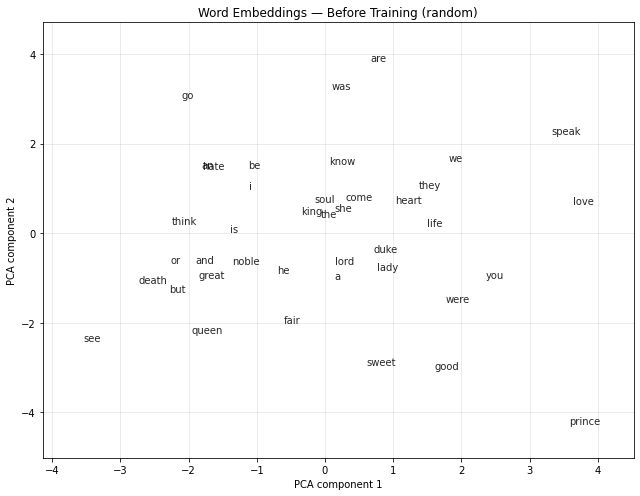

In [8]:
def pca_2d(vectors):
    """
    Project rows of `vectors` (shape: N x D) onto their top 2 principal
    components using a singular value decomposition.
    Returns an N x 2 array.

    Equivalently: this projects the (centred) data onto its two
    highest-variance directions.
    """
    # Centre the data so PCA captures variance, not absolute position
    centred = vectors - vectors.mean(axis=0, keepdims=True)
    # SVD: centred = U * diag(S) * Vt
    # The first two columns of U * diag(S) give the 2D projection.
    U, S, _ = np.linalg.svd(centred, full_matrices=False)
    return U[:, :2] * S[:2]


def plot_embeddings(model, words_to_show, title):
    """
    Plot the chosen words' embeddings in a 2D PCA projection.
    """
    # Pull the embedding matrix out as a NumPy array
    emb = model.embedding.weight.detach().numpy()  # shape (vocab_size, embed_dim)

    # Get the indices of the words we want to plot (skip any not in vocab)
    indices = [word_to_idx[w] for w in words_to_show if w in word_to_idx]
    chosen_words = [w for w in words_to_show if w in word_to_idx]

    coords = pca_2d(emb[indices])

    plt.figure(figsize=(9, 7))
    # Use semi-transparent text so word labels don't completely cover one another
    for (x, y), word in zip(coords, chosen_words):
        plt.text(x, y, word, fontsize=10, alpha=0.85,
                 ha='center', va='center')
    # Pad the axes a bit so labels near the edges aren't clipped
    pad_x = 0.1 * (coords[:, 0].max() - coords[:, 0].min() + 1e-9)
    pad_y = 0.1 * (coords[:, 1].max() - coords[:, 1].min() + 1e-9)
    plt.xlim(coords[:, 0].min() - pad_x, coords[:, 0].max() + pad_x)
    plt.ylim(coords[:, 1].min() - pad_y, coords[:, 1].max() + pad_y)
    plt.title(title)
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# A handful of words we expect to fall into recognisable groups after training:
# common articles/prepositions, pronouns, verbs, Shakespeare character names, etc.
words_to_show = [
    'the', 'a', 'an', 'and', 'or', 'but',
    'he', 'she', 'i', 'you', 'we', 'they',
    'king', 'queen', 'lord', 'lady', 'duke', 'prince',
    'love', 'hate', 'death', 'life', 'heart', 'soul',
    'come', 'go', 'speak', 'see', 'know', 'think',
    'is', 'was', 'are', 'were', 'be',
    'good', 'great', 'sweet', 'fair', 'noble',
]

plot_embeddings(model, words_to_show,
                title="Word Embeddings — Before Training (random)")

## 7. Train the Model

We use **cross-entropy loss** at every position of every sequence — exactly the same loss as the MLP digit classifier, but applied independently at every time step (and across a much larger vocabulary). At each position the network predicts a probability distribution over the next word, and the loss is large when the network is confidently wrong.

One quirk of RNNs is that the gradient of the loss has to flow backwards through every time step, multiplying matrices over and over. If those matrices have large entries, gradients can **explode** (become huge); if small, they can **vanish**. We address the first problem with **gradient clipping**: if the total gradient norm exceeds a threshold, we rescale it down. This is conceptually identical to limiting the step size in a numerical integrator to prevent it from blowing up.

Alongside the loss, we report **perplexity** — defined as $\exp(\text{loss})$. Perplexity has an intuitive meaning: it is the *effective number of words* the model is choosing among at each step. A perplexity of 50 means the model is, on average, as confused as if it were choosing uniformly among 50 words. Lower is better; the theoretical minimum is 1 (always certain and correct).

In [9]:
def evaluate(model, loader):
    """Return the mean cross-entropy loss per token on the given dataset."""
    model.eval()
    # reduction='sum' returns the total loss across all (position, sequence) pairs
    # in a batch, so we can divide by the true total number of tokens at the end.
    # This avoids a small bias from the final batch being smaller than the rest.
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():  # disable gradient tracking to save memory and time
        for inputs, targets in loader:
            logits, _ = model(inputs)
            # CrossEntropyLoss expects predictions of shape (N, C) and targets of shape (N,).
            # We flatten across both batch and time dimensions so each (position, sequence)
            # contributes one prediction-target pair.
            loss = criterion(
                logits.reshape(-1, model.vocab_size),
                targets.reshape(-1),
            )
            total_loss   += loss.item()
            total_tokens += targets.numel()

    return total_loss / total_tokens


def train(model, train_loader, test_loader, n_epochs=5, lr=0.002,
          clip=1.0, verbose=True):
    """
    Train the language model. Returns per-epoch (train_loss, test_loss) lists.

    Parameters
    ----------
    clip : float
        Maximum total gradient norm. Gradients are rescaled if they exceed this.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # default mean reduction is fine for training

    train_losses = []
    test_losses  = []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches  = 0

        for inputs, targets in train_loader:
            optimizer.zero_grad()

            # Forward pass: get logits at every position
            logits, _ = model(inputs)

            # Flatten batch and time dimensions for the loss computation
            loss = criterion(
                logits.reshape(-1, model.vocab_size),
                targets.reshape(-1),
            )

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients during BPTT
            # (Back-Propagation Through Time)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        train_loss = epoch_loss / n_batches
        test_loss  = evaluate(model, test_loader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if verbose:
            print(f"Epoch {epoch + 1:2d}/{n_epochs}  |  "
                  f"Train loss: {train_loss:.3f}  (perplexity {np.exp(train_loss):6.1f})  |  "
                  f"Test loss: {test_loss:.3f}  (perplexity {np.exp(test_loss):6.1f})")

    return train_losses, test_losses

In [10]:
# Train the default model — this typically takes a few minutes on a CPU.
# Three epochs is enough to make the learning visible without letting the
# small training set overfit too much; you can raise this if you like.
model = RNNLanguageModel(vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=64)
train_losses, test_losses = train(model, train_loader, test_loader, n_epochs=3)

Epoch  1/3  |  Train loss: 5.288  (perplexity  198.0)  |  Test loss: 5.699  (perplexity  298.6)
Epoch  2/3  |  Train loss: 4.526  (perplexity   92.3)  |  Test loss: 5.997  (perplexity  402.4)
Epoch  3/3  |  Train loss: 4.209  (perplexity   67.3)  |  Test loss: 6.287  (perplexity  537.6)


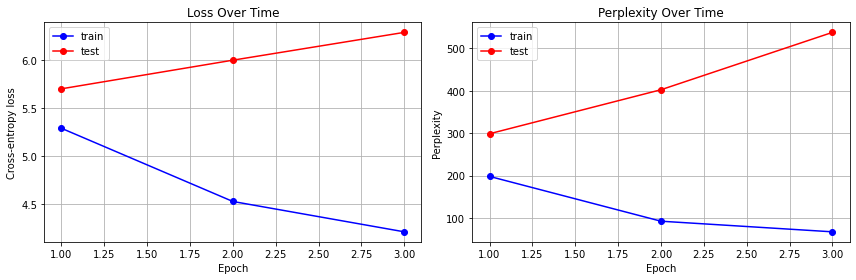

In [11]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, 'b-o', label='train')
ax1.plot(epochs, test_losses,  'r-o', label='test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Loss Over Time')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, np.exp(train_losses), 'b-o', label='train')
ax2.plot(epochs, np.exp(test_losses),  'r-o', label='test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity Over Time')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### A note on what these curves show — overfitting

Look carefully at the two curves: the **training loss decreases steadily across all three epochs**, but the **test loss *increases* monotonically** over the same epochs (epoch 1 test loss ≈ 5.70, epoch 3 test loss ≈ 6.29). The model is getting better at predicting training text and worse at predicting held-out text. This is the textbook signature of **overfitting**.

Overfitting means the model is starting to *memorise* its training data instead of learning patterns that generalise. The training plays are full of specific names ("gloucester", "tybalt"), specific dialogue tags, and specific phrasings that don't appear (or appear differently) in the held-out plays we use for testing. With around 490,000 trainable parameters and only ~180,000 training tokens, the network has more than enough capacity to start memorising — and once it does, its predictions on never-seen text get *worse*.

This should feel familiar from physics: if you fit a polynomial of very high degree to a small data set, the fit goes through every training point but oscillates wildly between them, and it predicts new measurements very badly. Same idea — too many free parameters, not enough data.

The usual ways to fight overfitting are:
- **Stop training early** (so-called *early stopping*) at the epoch where test loss is lowest — here that would be after epoch 1.
- **Use a smaller model** (we already shrank `hidden_dim` and `embed_dim` for this reason).
- **Get more training data**, or apply *regularisation* like `nn.Dropout`.
- **Use a stronger architecture** (LSTM/GRU/Transformer) that learns more efficiently per parameter.

For the rest of this notebook we just live with the overfitting — the model is still good enough to generate recognisably Shakespeare-like text, even if it isn't competitive on perplexity.

## 8. Visualise Embeddings — After Training

Now let's re-plot the same word embeddings. Training should have pulled related words together: pronouns near pronouns, royal titles near each other, common articles in one corner, and so on.

The geometry won't be perfect — a small RNN trained for only a few epochs can only do so much — but the difference from the random scatter above should be visible.

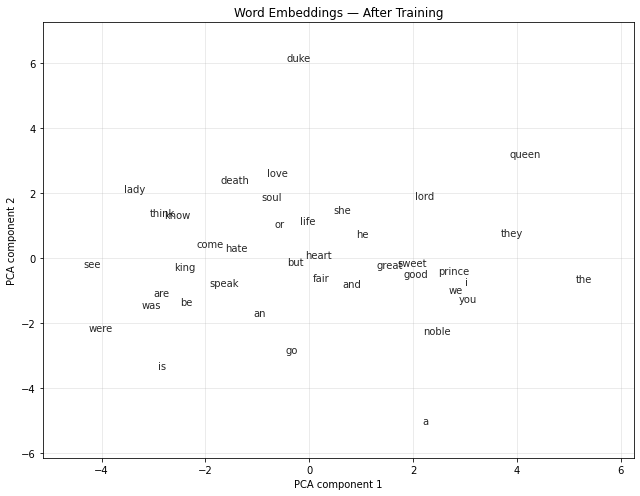

In [12]:
plot_embeddings(model, words_to_show,
                title="Word Embeddings — After Training")

## 9. Complete a Sentence

We now use the trained model to generate text. The procedure is:

1. Tokenise the prompt.
2. Feed it through the model to get a probability distribution over the next word.
3. Pick a next word — either the most likely one (**greedy**) or a sample from the distribution (**sampling**).
4. Append it to the sequence and repeat.

**One small but important detail:** when we pick the next word, we *mask out* the `<unk>` token (we set its score to $-\infty$ before the softmax, so it gets probability zero). Roughly 12 % of our training tokens were `<unk>`, so the model has learned that `<unk>` is a very high-probability guess — and without this mask the generated text would be full of `"<unk>"` placeholders rather than real words.

We expose a `temperature` parameter that controls how adventurous the sampling is. Logits are divided by the temperature before being turned into probabilities:

- **Small temperature** (e.g. `0.1`): almost always picks the single most likely word (deterministic, often repetitive).
- `temperature = 1`: samples from the model's raw probability distribution.
- `temperature > 1`: flattens the distribution, encouraging surprising choices (often nonsensical).

This is exactly analogous to the *temperature* parameter in a Boltzmann distribution: lower temperature means more concentration on the highest-probability word (analogous to the ground state of a Boltzmann distribution at low T), and higher temperature spreads probability more evenly across the vocabulary (higher entropy).

In [13]:
UNK_INDEX = word_to_idx['<unk>']  # always 0, but using the lookup is safer


def complete_sentence(model, prompt, n_words=10, temperature=0.8, greedy=False):
    """
    Continue `prompt` for `n_words` more words using the trained model.

    Parameters
    ----------
    prompt : str
        Initial text. Will be lower-cased and split on whitespace.
    n_words : int
        How many words to generate.
    temperature : float
        Controls randomness of sampling. Clamped to a small positive value
        to avoid divide-by-zero. Ignored if greedy=True.
    greedy : bool
        If True, always pick the single most likely next word.

    Notes
    -----
    The <unk> token is *masked out* when choosing the next word — about 12 %
    of training tokens were <unk>, so the model would otherwise predict it
    very often and the generated text would be full of "<unk>" placeholders.
    """
    model.eval()

    # Tokenise the prompt the same way we tokenised the training data
    prompt_tokens = prompt.lower().split()
    if len(prompt_tokens) == 0:
        raise ValueError("prompt must contain at least one word")
    indices = [word_to_idx.get(w, 0) for w in prompt_tokens]

    # Warn if any prompt words fell outside the vocabulary — they'll be
    # silently treated as <unk>, which often produces strange completions.
    unknown = [w for w in prompt_tokens if w not in word_to_idx]
    if unknown:
        print(f"Note: prompt words not in vocab (treated as <unk>): {unknown}")

    # Guard against divide-by-zero if a user passes temperature=0.
    safe_temperature = max(float(temperature), 1e-3)

    generated = list(prompt_tokens)

    with torch.no_grad():
        # Start with the prompt as a single batch of one sequence
        x = torch.tensor([indices], dtype=torch.long)  # shape (1, prompt_len)
        logits, hidden = model(x)

        for _ in range(n_words):
            # The next-word distribution lives at the *last* time step.
            # logits shape: (1, seq_len, vocab_size); take logits[0, -1, :].
            next_logits = logits[0, -1, :].clone()

            # Mask <unk> so it can never be chosen: setting its logit to -inf
            # gives it probability zero under softmax.
            next_logits[UNK_INDEX] = float('-inf')

            if greedy:
                next_idx = int(next_logits.argmax().item())
            else:
                # Scale by temperature and convert to probabilities
                probs = torch.softmax(next_logits / safe_temperature, dim=-1)
                # torch.multinomial samples one index according to `probs`
                next_idx = int(torch.multinomial(probs, num_samples=1).item())

            generated.append(idx_to_word[next_idx])

            # Feed just the newly chosen word back in, reusing the hidden state.
            # This is much faster than re-running the whole sequence each time.
            x = torch.tensor([[next_idx]], dtype=torch.long)
            logits, hidden = model(x, hidden)

    return ' '.join(generated)


# A few example prompts. Greedy decoding is deterministic and often picks
# safe / common words. Sampling produces more varied outputs.
example_prompts = [
    "to be or not to",
    "my lord, the king is",
    "what light through yonder",
    "o romeo, romeo, wherefore",
]

print("--- Greedy (always pick most likely next word) ---\n")
for p in example_prompts:
    print(f"  prompt    : {p!r}")
    print(f"  completion: {complete_sentence(model, p, n_words=8, greedy=True)}\n")

print("\n--- Sampling with temperature=0.8 ---\n")
for p in example_prompts:
    print(f"  prompt    : {p!r}")
    print(f"  completion: {complete_sentence(model, p, n_words=8, temperature=0.8)}\n")

--- Greedy (always pick most likely next word) ---

  prompt    : 'to be or not to'
  completion: to be or not to be revenged to the duke of york. king

  prompt    : 'my lord, the king is'
  completion: my lord, the king is not yet not to the king and be

  prompt    : 'what light through yonder'
  completion: what light through yonder is the hand of war. camillo: i have

  prompt    : 'o romeo, romeo, wherefore'
  completion: o romeo, romeo, wherefore do not be of your house: and i


--- Sampling with temperature=0.8 ---

  prompt    : 'to be or not to'
  completion: to be or not to tell my gentle was the pattern of the

  prompt    : 'my lord, the king is'
  completion: my lord, the king is dead. bona: your son, and kiss the queen?

  prompt    : 'what light through yonder'
  completion: what light through yonder is our death. and most peace, i'll not

  prompt    : 'o romeo, romeo, wherefore'
  completion: o romeo, romeo, wherefore shall not teach it, for the king, that



## 10. Effect of Hidden-State Size and Context Window

Just as we explored MLP depth and width in the previous module, here we explore the two most important hyperparameters of a plain RNN:

- **`hidden_dim`** — how many numbers the model uses to summarise its history. Larger means more capacity (more "memory") and more parameters, but as we saw in the previous section, more capacity on this small dataset can also mean *more overfitting*. So we should expect a sweet spot rather than a clean "bigger is better" trend.
- **`seq_len`** — how many words of context the model is asked to learn from at training time. Longer means more chances to learn long-range dependencies, but also harder to optimise because gradients must flow further back in time.

We train several small models for a single epoch each (to keep runtime reasonable) and compare their test-set perplexity. One epoch is not enough to fully train any of them, but it's enough to see how their final perplexities order themselves.

> **Heads up on runtime.** The two sweeps below train eight models from scratch in total. Even at one epoch each, this section can take **5–10 minutes** on a typical laptop CPU. For more reliable trends, bump `n_epochs` up to `2` or `3` if you have the time.

hidden_dim =   16  (245,800 parameters)
  final test perplexity: 316.2

hidden_dim =   32  (327,112 parameters)
  final test perplexity: 282.9

hidden_dim =   64  (491,272 parameters)
  final test perplexity: 298.7

hidden_dim =  128  (825,736 parameters)
  final test perplexity: 382.4



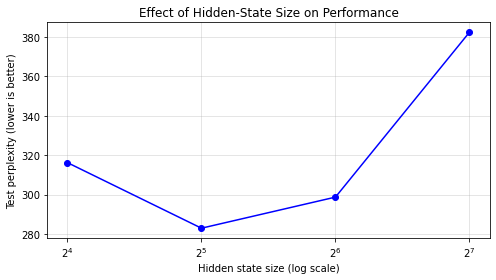

In [14]:
# Sweep over hidden-state size at fixed seq_len = 20, embed_dim = 32
hidden_sizes = [16, 32, 64, 128]
hidden_results = []

for h in hidden_sizes:
    m = RNNLanguageModel(vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=h)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"hidden_dim = {h:4d}  ({n_params:,} parameters)")
    _, te = train(m, train_loader, test_loader, n_epochs=1, verbose=False)
    final_perplexity = np.exp(te[-1])
    hidden_results.append(final_perplexity)
    print(f"  final test perplexity: {final_perplexity:.1f}\n")

plt.figure(figsize=(7, 4))
plt.plot(hidden_sizes, hidden_results, 'b-o')
plt.xscale('log', base=2)
plt.xlabel('Hidden state size (log scale)')
plt.ylabel('Test perplexity (lower is better)')
plt.title('Effect of Hidden-State Size on Performance')
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

seq_len =   5
  final test perplexity: 298.7

seq_len =  10
  final test perplexity: 294.2

seq_len =  20
  final test perplexity: 304.3

seq_len =  40
  final test perplexity: 308.4



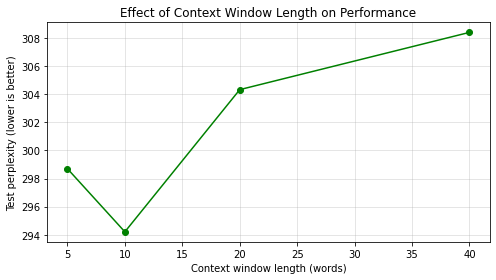

In [15]:
# Sweep over context-window length at fixed hidden_dim = 64, embed_dim = 32
context_lengths = [5, 10, 20, 40]
context_results = []

for sl in context_lengths:
    # Build new sequence tensors and loaders for this context length
    tr_in, tr_tg = make_sequences(train_data, sl)
    te_in, te_tg = make_sequences(test_data,  sl)
    tr_loader = DataLoader(TensorDataset(tr_in, tr_tg), batch_size=BATCH_SIZE, shuffle=True)
    te_loader = DataLoader(TensorDataset(te_in, te_tg), batch_size=BATCH_SIZE, shuffle=False)

    m = RNNLanguageModel(vocab_size=VOCAB_SIZE, embed_dim=32, hidden_dim=64)
    print(f"seq_len = {sl:3d}")
    _, te = train(m, tr_loader, te_loader, n_epochs=1, verbose=False)
    final_perplexity = np.exp(te[-1])
    context_results.append(final_perplexity)
    print(f"  final test perplexity: {final_perplexity:.1f}\n")

plt.figure(figsize=(7, 4))
plt.plot(context_lengths, context_results, 'g-o')
plt.xlabel('Context window length (words)')
plt.ylabel('Test perplexity (lower is better)')
plt.title('Effect of Context Window Length on Performance')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Try Your Own Prompt

Edit `prompt` to anything you like (Shakespearean phrasing tends to work best), set `n_words_to_generate`, and run the cell. The bar chart shows the model's top-10 candidates for the *very next* word — its predicted distribution at that single position, with `<unk>` masked out so we only see real-word candidates.

Prompt    : to be or not to
Completion: to be or not to my sovereign and we have made a tall fellow of woe, and


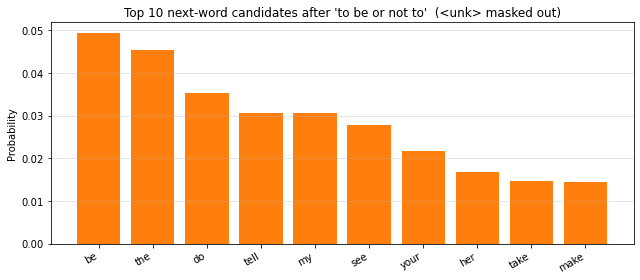

In [16]:
# -------------------------------------------------------
prompt = "to be or not to"
n_words_to_generate = 12
temperature = 0.8     # try 0.5 (more conservative) or 1.2 (more adventurous)
# -------------------------------------------------------

# Warn the user if any prompt words are outside the 5,000-word vocabulary.
# Such words are silently replaced with <unk> internally, which usually
# produces strange completions — this print makes the substitution visible.
unknown_words = [w for w in prompt.lower().split() if w not in word_to_idx]
if unknown_words:
    print(f"Note: these prompt words are not in the vocab and will be "
          f"treated as <unk>: {unknown_words}\n")

# 1. Generate a continuation (<unk> is masked out inside complete_sentence)
completion = complete_sentence(
    model, prompt, n_words=n_words_to_generate, temperature=temperature,
)
print("Prompt    :", prompt)
print("Completion:", completion)

# 2. Look at the model's predicted next-word distribution given just the prompt
model.eval()
prompt_indices = [word_to_idx.get(w, 0) for w in prompt.lower().split()]
with torch.no_grad():
    logits, _ = model(torch.tensor([prompt_indices], dtype=torch.long))
    # Mask <unk> here too, so the bar chart shows *real* word candidates
    final_logits = logits[0, -1, :].clone()
    final_logits[UNK_INDEX] = float('-inf')
    probs = torch.softmax(final_logits, dim=-1).numpy()

# Find the top 10 candidates
top_k = 10
top_indices = np.argsort(probs)[::-1][:top_k]
top_words   = [idx_to_word[i] for i in top_indices]
top_probs   = probs[top_indices]

plt.figure(figsize=(9, 4))
plt.bar(range(top_k), top_probs, color='tab:orange')
plt.xticks(range(top_k), top_words, rotation=30, ha='right')
plt.ylabel('Probability')
plt.title(f"Top {top_k} next-word candidates after {prompt!r}  (<unk> masked out)")
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. **Downloaded and tokenised** the Tiny Shakespeare corpus into a word-level integer sequence, capping the vocabulary at 5,000 to handle rare words sensibly.
2. **Built training sequences** by sliding a fixed-length window over the corpus, with each input position paired to the next word as its target.
3. **Defined an RNN language model**: embedding -> RNN -> linear output, predicting a next-word distribution at every time step.
4. **Visualised word embeddings before training** — a featureless cloud.
5. **Trained the network** with cross-entropy loss, the Adam optimiser, and gradient clipping (which keeps gradients from exploding during back-propagation through time), and saw the textbook overfitting pattern: training loss falling while test loss rises.
6. **Visualised embeddings after training** — related words have moved closer together.
7. **Generated text** by repeatedly sampling the model's predicted next word (with `<unk>` masked out), using a temperature parameter that mirrors the Boltzmann temperature controlling stochasticity.
8. **Explored hyperparameters** — how hidden-state size and context-window length affect test perplexity, finding a "Goldilocks" sweet spot rather than a monotonic improvement.

### Things to try
- Train for many more epochs (`n_epochs=10` or `20`) — how much worse does the test loss get as the model memorises harder?
- Increase `VOCAB_SIZE` to 10,000 and see whether the `<unk>` fraction drops meaningfully.
- Try very low (`0.2`) and very high (`1.5`) temperatures with `complete_sentence` — what's the trade-off?
- Stack multiple RNN layers by passing `n_layers=2` (or `3`) when constructing the model — does deeper help, or does training get harder?
- Swap `nn.RNN` for `nn.LSTM` in the model definition — LSTMs add learned "gates" that decide what to keep in memory and what to forget, and they usually train more stably on long sequences. (You will also need to handle the LSTM's tuple-valued hidden state, which contains both a hidden vector *and* a cell-state vector.)